In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set_theme(style="whitegrid")

In [2]:
# Load central data
print("Loading Central Data...")
X_train_global = np.load("../data/processed/X_train.npy")
X_test_global = np.load("../data/processed/X_test.npy")
y_test_global = np.load("../data/processed/y_test.npy", allow_pickle=True)

print(f"Total Training Data: {len(X_train_global)} samples")

# Define Upgraded FALCON Model with L1 Regularization
def build_falcon_model(input_dim=21):
    input_layer = layers.Input(shape=(input_dim,))
    encoded = layers.Dense(16, activation='relu')(input_layer)
    
    # NEW: L1 Regularizer added to the bottleneck
    encoded = layers.Dense(8, activation='relu', activity_regularizer=regularizers.l1(1e-5))(encoded)
    
    decoded = layers.Dense(16, activation='relu')(encoded)
    output_layer = layers.Dense(input_dim, activation='linear')(decoded)

    model = models.Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer='adam', loss='mse')
    return model

print("Upgraded FALCON Architecture Ready.")

Loading Central Data...
Total Training Data: 1818477 samples
Upgraded FALCON Architecture Ready.


In [17]:
# Create 3 Clients
print("Partitioning Data for 3 Clients...")
client_1_data, rest_data = train_test_split(X_train_global, test_size=0.66, random_state=42)
client_2_data, client_3_data = train_test_split(rest_data, test_size=0.5, random_state=42)

clients = [client_1_data, client_2_data, client_3_data]
client_names = ['A', 'B', 'C']

print("------Data Distribution------")
print(f"Client A: {client_1_data.shape} samples")
print(f"Client B: {client_2_data.shape} samples")
print(f"Client C: {client_3_data.shape} samples")

Partitioning Data for 3 Clients...
------Data Distribution------
Client A: (618282, 21) samples
Client B: (600097, 21) samples
Client C: (600098, 21) samples


## Latent Consensus Module

In [18]:
def falcon_latent_consensus_aggregator(local_weights_list, global_weights, client_names, rejection_multiplier=2.0):
    """
    Evaluates client model updates, calculates divergence from the global consensus,
    rejects poisoned/outlier updates, and returns the new aggregated global weights.
    """
    print("   [Server] Evaluating Client Updates (Latent Consensus)...")
    
    # 1. Calculate Weight Divergence (Distance from Global)
    client_distances = []
    for client_weights in local_weights_list:
        dist = np.sum([np.linalg.norm(cw - gw) for cw, gw in zip(client_weights, global_weights)])
        client_distances.append(dist)
        
    for i, name in enumerate(client_names):
        print(f"      -> Client {name} Divergence Score: {client_distances[i]:.4f}")
        
    # 2. Consensus Filtering (Median-based Outlier Rejection)
    median_dist = np.median(client_distances)
    rejection_threshold = median_dist * rejection_multiplier
    
    accepted_weights = []
    for i, dist in enumerate(client_distances):
        if dist <= rejection_threshold:
            accepted_weights.append(local_weights_list[i])
        else:
            print(f"      !!! DEFENSE TRIGGERED: Client {client_names[i]} REJECTED (Outlier/Poison detected).")
            
    # 3. Aggregate ONLY the accepted, high-quality clients
    print(f"   [Server] Aggregating {len(accepted_weights)} Accepted Clients...")
    new_global_weights = []
    for layer_weights_tuple in zip(*accepted_weights):
        averaged_layer = np.mean(np.array(layer_weights_tuple), axis=0)
        new_global_weights.append(averaged_layer)

    return new_global_weights

In [19]:
# Federated Learning Simulation Setup
ROUNDS = 5     
EPOCHS_PER_ROUND = 1     

global_model = build_falcon_model()
global_weights = global_model.get_weights()

history_f1 = []

# Pre-convert labels to binary for later evaluations
y_true_numeric = np.array([0 if str(label).strip().upper() == 'BENIGN' else 1 for label in y_test_global])

print(f"Starting FALCON Federated Training for {ROUNDS} Rounds...\n")

for round_num in range(1, ROUNDS + 1):
    print(f"\n--- Round {round_num}/{ROUNDS} ---")
    local_weights_list = []

    # Phase 1: Local Client Training
    for i, client_data in enumerate(clients):
        local_model = build_falcon_model()
        local_model.set_weights(global_weights)
        local_model.fit(client_data, client_data, epochs=EPOCHS_PER_ROUND, batch_size=256, verbose=0)
        
        weights = local_model.get_weights()
        
        # # --- POISON ATTACK SIMULATION (Round 3, Client C) ---
        # if round_num == 3 and client_names[i] == 'C':
        #     print(f"   [!] SIMULATING ATTACK: Poisoning Client {client_names[i]}'s weights...")
        #     weights = [w + np.random.normal(0.5, 2.0, w.shape) for w in weights]
            
        local_weights_list.append(weights)
        print(f" * Client {client_names[i]} finished training.")

    # Phase 2: Server Aggregation (Latent Consensus)
    global_weights = falcon_latent_consensus_aggregator(local_weights_list, global_weights, client_names)
    global_model.set_weights(global_weights)

    # Phase 3: Round Monitoring
    reconstructions = global_model.predict(X_test_global, batch_size=4096, verbose=0)
    mse = np.mean(np.power(X_test_global - reconstructions, 2), axis=1)
    
    round_threshold = np.percentile(mse, 95)
    y_pred = [1 if e > round_threshold else 0 for e in mse]
    
    f1 = f1_score(y_true_numeric, y_pred)
    history_f1.append(f1)
    print(f"   [Server] Global Model F1 Score (Estimated): {f1:.4f}")

print("\nFederated Training Complete!")

Starting FALCON Federated Training for 5 Rounds...


--- Round 1/5 ---
 * Client A finished training.
 * Client B finished training.
 * Client C finished training.
   [Server] Evaluating Client Updates (Latent Consensus)...
      -> Client A Divergence Score: 17.9931
      -> Client B Divergence Score: 17.2302
      -> Client C Divergence Score: 17.9944
   [Server] Aggregating 3 Accepted Clients...
   [Server] Global Model F1 Score (Estimated): 0.1413

--- Round 2/5 ---
 * Client A finished training.
 * Client B finished training.
 * Client C finished training.
   [Server] Evaluating Client Updates (Latent Consensus)...
      -> Client A Divergence Score: 10.5848
      -> Client B Divergence Score: 11.1301
      -> Client C Divergence Score: 10.2283
   [Server] Aggregating 3 Accepted Clients...
   [Server] Global Model F1 Score (Estimated): 0.1657

--- Round 3/5 ---
 * Client A finished training.
 * Client B finished training.
 * Client C finished training.
   [Server] Evaluating Clien

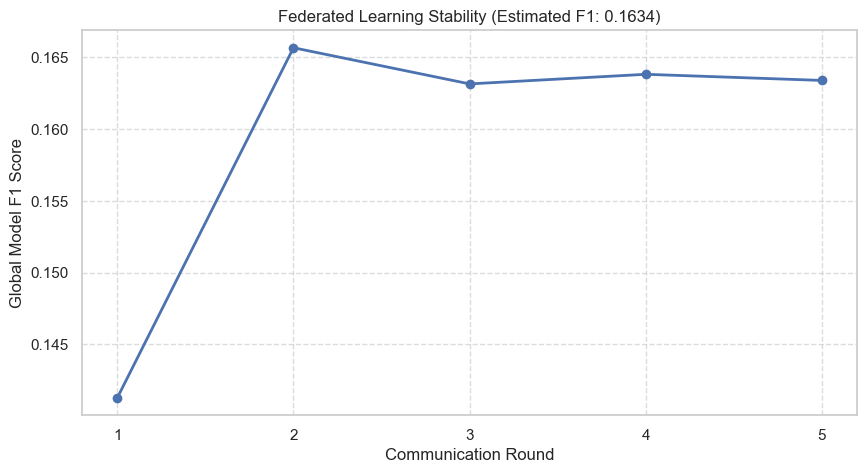

In [20]:
# Learning Curve Visualization
plt.figure(figsize=(10,5))
plt.plot(range(1, ROUNDS + 1), history_f1, marker='o', linestyle='-', color='b', linewidth=2)
plt.title(f"Federated Learning Stability (Estimated F1: {history_f1[-1]:.4f})")
plt.xlabel("Communication Round")
plt.ylabel("Global Model F1 Score")
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(range(1, ROUNDS + 1))
plt.show()

In [24]:
print("Evaluating Final Global Model using Dynamic Threshold Sweeper...")

# 1. Predict on Benign Training Data to find the strict baseline
reconstructions_train = global_model.predict(X_train_global, batch_size=4096, verbose=0)
mse_train = np.mean(np.power(X_train_global - reconstructions_train, 2), axis=1)

# 2. Predict on Test Data
reconstructions_test = global_model.predict(X_test_global, batch_size=4096, verbose=0)
mse_test = np.mean(np.power(X_test_global - reconstructions_test, 2), axis=1)

print("\nSweeping percentiles to find the optimal global anomaly boundary...")
best_f1 = 0
best_p = 0
best_thresh = 0

# 3. Sweep from 85th to 99.5th percentile
for p in np.arange(85.0, 99.5, 0.5):
    thresh = np.percentile(mse_train, p)
    
    y_pred = (mse_test > thresh).astype(int)
    f1 = f1_score(y_true_numeric, y_pred)
    
    if f1 > best_f1:
        best_f1 = f1
        best_p = p
        best_thresh = thresh

# 4. Save and apply best threshold
optimal_threshold = best_thresh
print(f"Optimal Global Training Percentile: {best_p}th")
print(f"Strict Global Normal Threshold: {optimal_threshold:.6f}")

# Final Predictions with the swept threshold
y_pred_optimal = (mse_test > optimal_threshold).astype(int)

accuracy = accuracy_score(y_true_numeric, y_pred_optimal)
precision = precision_score(y_true_numeric, y_pred_optimal)
recall = recall_score(y_true_numeric, y_pred_optimal)

print(f"\n--- ProjectFALCON Federated Performance ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"F1 Score:  {best_f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")

Evaluating Final Global Model using Dynamic Threshold Sweeper...

Sweeping percentiles to find the optimal global anomaly boundary...
Optimal Global Training Percentile: 85.0th
Strict Global Normal Threshold: 0.001071

--- ProjectFALCON Federated Performance ---
Accuracy:  0.8557
F1 Score:  0.8680
Precision: 0.8748
Recall:    0.8613


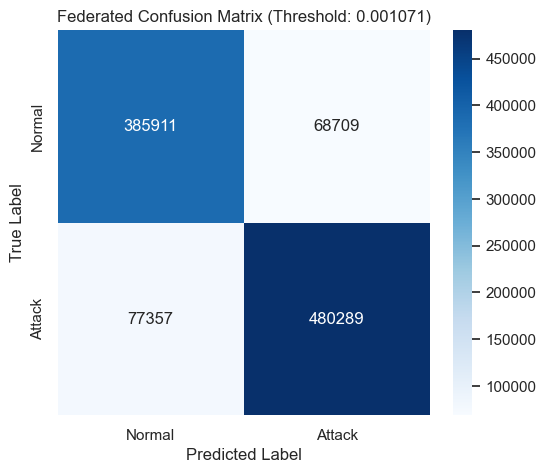

In [22]:
# Confusion Matrix
cm = confusion_matrix(y_true_numeric, y_pred_optimal)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.title(f"Federated Confusion Matrix (Threshold: {optimal_threshold:.6f})")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

/Users/sujannainawasti/miniconda3/envs/fl_project/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


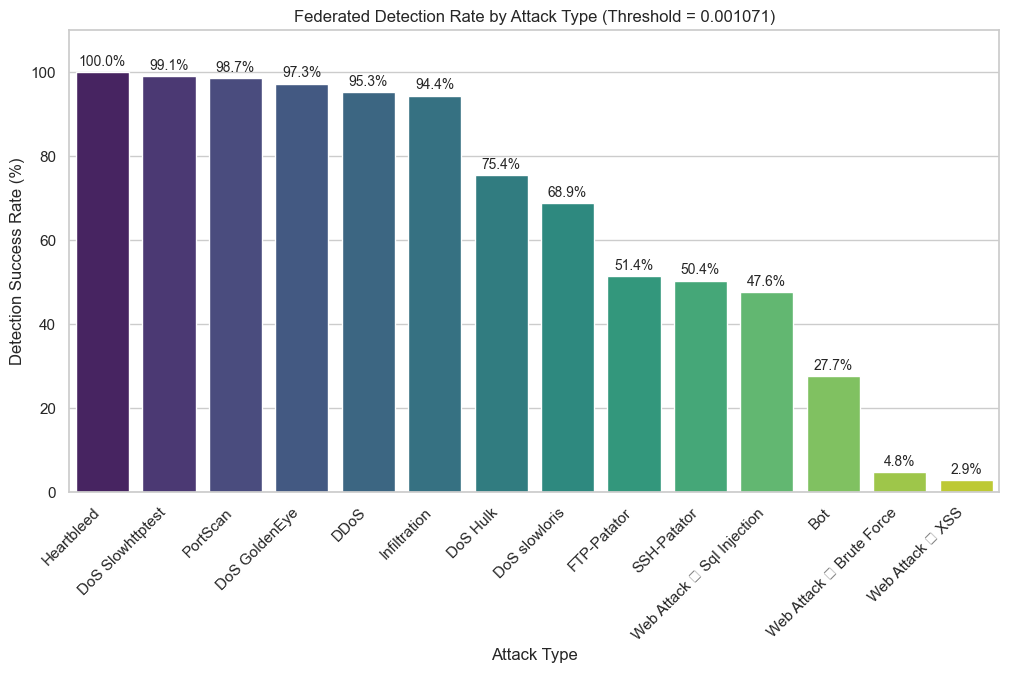

In [23]:
# Attack Detection Breakdown
raw_labels = [str(label).strip() for label in y_test_global]
breakdown_df = pd.DataFrame({
    'Attack_Type': raw_labels,
    'Predicted_Status': ['Detected' if p == 1 else 'Missed' for p in y_pred_optimal]
})

attack_df = breakdown_df[breakdown_df['Attack_Type'] != 'BENIGN']
detection_stats = attack_df.groupby('Attack_Type')['Predicted_Status'].value_counts(normalize=True).unstack().fillna(0)

if "Detected" not in detection_stats.columns:
    detection_stats['Detected'] = 0.0

detection_rates = detection_stats['Detected'] * 100
detection_rates = detection_rates.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
# Setting hue to the index and legend=False fixes the Seaborn warning
sns.barplot(x=detection_rates.index, y=detection_rates.values, hue=detection_rates.index, palette='viridis', legend=False)
plt.title(f"Federated Detection Rate by Attack Type (Threshold = {optimal_threshold:.6f})")
plt.ylabel("Detection Success Rate (%)")
plt.xlabel("Attack Type")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 110)

for i, v in enumerate(detection_rates.values):
    plt.text(i, v + 1.5, f"{v:.1f}%", ha='center', fontsize=10)

plt.show()